# 03 - Backtest: Regime-Based Allocation for a Euro Investor

**Question:** if an investor had followed the regime model in real time, with publication lags and trading costs, would they have done better than a static portfolio?

**Inputs:** `data/returns_eur.csv`, `data/returns_usd.csv`, `data/regimes.csv`
**Period:** 2006 – September 2026 (monthly)

## 1. Design

**Investor:** euro-based, using euro returns and Euro area regimes.

**Avoiding look-ahead bias:**
- **Publication lags.** A regime can only be used once all its data has been published. For the Euro area, the Economic Sentiment Indicator and Eurostat's flash inflation estimate are both published at the end of the month they describe, so the September regime is known by early October and can first be used for October returns: a **1-month lag**. For the US, CPI and industrial production are published around mid-month, so the lag is **2 months**.
- **Tilts set in advance.** The regime tilts are based on economic reasoning, not on the results of `02_asset_returns`. Choosing tilts from the same data used to test them would make the backtest look better than it could have been in reality.

**Trading costs:** 0.1% of every euro traded. Portfolios are rebalanced monthly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns_eur = pd.read_csv("../data/returns_eur.csv", index_col=0, parse_dates=True)
returns_usd = pd.read_csv("../data/returns_usd.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv("../data/regimes.csv", index_col=0, parse_dates=True)

LAG_EA = 1
LAG_US = 2

signal_ea = regimes["ea_regime"].shift(LAG_EA, freq="MS")
signal_us = regimes["us_regime"].shift(LAG_US, freq="MS")

pd.DataFrame({"ea_regime": regimes["ea_regime"], "signal_ea": signal_ea}).loc["2020-01":"2020-08"]

,ea_regime,signal_ea
2020-01-01,Overheating,Stagflation
2020-02-01,Overheating,Overheating
2020-03-01,Slowdown,Overheating
2020-04-01,Slowdown,Slowdown
2020-05-01,Slowdown,Slowdown
2020-06-01,Slowdown,Slowdown
2020-07-01,Slowdown,Slowdown
2020-08-01,Slowdown,Slowdown


## 2. Portfolio weights

The strategy starts from a neutral portfolio and tilts it according to the regime.

| Asset | Neutral | Goldilocks | Overheating | Slowdown | Stagflation |
|---|---|---|---|---|---|
| SPY (US equities) | 25 | +10 | +5 | −5 | −10 |
| VGK (European equities) | 20 | +10 | +5 | −10 | −10 |
| TLT (long Treasuries) | 20 | | −10 | +10 | −5 |
| LQD (IG credit) | 10 | | −10 | | |
| SHY (short Treasuries) | 10 | −10 | | +5 | +10 |
| GLD (gold) | 10 | −10 | | +5 | +10 |
| DBC (commodities) | 5 | | +10 | −5 | +5 |

**Reasoning:**
- **Goldilocks:** profits grow and rates stay low → more equities, less protection (cash, gold).
- **Overheating:** strong demand and rising prices → more commodities; central banks raise rates → fewer long bonds and less credit.
- **Slowdown:** central banks cut rates → more long bonds and gold; the dollar tends to rise → more short US Treasuries (dollar cash for a euro investor); fewer equities and commodities.
- **Stagflation:** profits fall and rates rise → fewer equities and long bonds; more cash, gold and commodities.

Tilts sum to zero in each regime (always 100% invested) and no weight goes below zero (no short positions). Both conditions are checked with `assert`.

In [2]:
neutral = pd.Series({"SPY": 25, "VGK": 20, "TLT": 20, "LQD": 10, "SHY": 10, "GLD": 10, "DBC": 5})

tilts = pd.DataFrame({
    "Goldilocks":  {"SPY": 10, "VGK": 10, "SHY": -10, "GLD": -10},
    "Overheating": {"SPY": 5, "VGK": 5, "TLT": -10, "LQD": -10, "DBC": 10},
    "Slowdown":    {"SPY": -5, "VGK": -10, "TLT": 10, "SHY": 5, "GLD": 5, "DBC": -5},
    "Stagflation": {"SPY": -10, "VGK": -10, "TLT": -5, "SHY": 10, "GLD": 10, "DBC": 5},
}).fillna(0)

regime_weights = tilts.add(neutral, axis=0) / 100
assert np.allclose(regime_weights.sum(), 1), "Weights don't sum to 1"
assert (regime_weights >= 0).all().all(), "Negative weight found"
regime_weights


,Goldilocks,Overheating,Slowdown,Stagflation
DBC,0.05,0.15,0.00,0.10
GLD,0.00,0.10,0.15,0.20
LQD,0.10,0.00,0.10,0.10
SHY,0.00,0.10,0.15,0.20
SPY,0.35,0.30,0.20,0.15
TLT,0.20,0.10,0.30,0.15
VGK,0.30,0.25,0.10,0.10


## 3. Backtest method

Each month:
1. The lagged regime signal selects that month's weights.
2. The portfolio return is the weighted sum of the asset returns.
3. **Turnover** is the total change in weights since the previous month (moving 10% from equities to bonds = 20% turnover).
4. Trading costs (turnover × 0.1%) are subtracted.

**Benchmarks:**
- **Neutral:** the neutral weights, never changed. This is the fair comparison, since the strategy starts from the same portfolio.
- **60/40:** 30% US equities, 30% European equities, 40% long Treasuries.

**Simplification:** benchmarks are assumed to stay exactly at their weights with no trading costs. In reality they would drift and need small rebalancing trades. This slightly flatters the benchmarks, making the test harder for the strategy, not easier.

In [3]:
COST = 0.001

def backtest(returns, signal, regime_weights, cost=COST):
    signal = signal.dropna()
    dates = returns.index.intersection(signal.index)

    weights = regime_weights.T.loc[signal.loc[dates]].set_axis(dates)
    weights = weights[returns.columns]

    gross = (weights * returns.loc[dates]).sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    net = gross - turnover * cost

    return net, weights, turnover

strategy, weights_ea, turnover_ea = backtest(returns_eur, signal_ea, regime_weights)

In [4]:
def static_portfolio(returns, w):
    return (returns[w.index] * w).sum(axis=1)

w_6040 = pd.Series({"SPY": 0.30, "VGK": 0.30, "TLT": 0.40})
w_neutral = neutral / 100

results = pd.DataFrame({
    "Regime strategy": strategy,
    "Neutral": static_portfolio(returns_eur, w_neutral),
    "60/40": static_portfolio(returns_eur, w_6040),
}).dropna()

growth = 100 * (1 + results).cumprod()
growth.tail(1).round(1)

,Regime strategy,Neutral,60/40
2026-09-01,495.2,406.0,400.1


In [5]:
def performance(r):
    years = len(r) / 12
    wealth = (1 + r).cumprod()

    annual_return = wealth.iloc[-1] ** (1 / years) - 1
    volatility = r.std() * np.sqrt(12)
    drawdown = wealth / wealth.cummax() - 1

    return pd.Series({
        "Annual return (%)": annual_return * 100,
        "Volatility (%)": volatility * 100,
        "Return / volatility": annual_return / volatility,
        "Max drawdown (%)": drawdown.min() * 100,
    })

stats = results.apply(performance)
stats.round(2)

,Regime strategy,Neutral,60/40
Annual return (%),8.08,7.04,6.97
Volatility (%),8.55,8.03,9.74
Return / volatility,0.95,0.88,0.72
Max drawdown (%),-13.54,-16.25,-24.50


## 4. Results (Euro area regimes, 1-month lag, after costs)

| | Regime strategy | Neutral | 60/40 |
|---|---|---|---|
| Annual return | 8.08% | 7.04% | 6.97% |
| Volatility | 8.55% | 8.03% | 9.74% |
| Return / volatility | 0.95 | 0.88 | 0.72 |
| Max drawdown | −13.5% | −16.3% | −24.5% |

*Return / volatility is a simplified Sharpe ratio, without subtracting the risk-free rate.*

Over the full period, the strategy earned about **1 percentage point a year** more than the neutral portfolio, with a better risk-adjusted return and a smaller worst loss. Sections 6 and 7 test how robust this result is.

The neutral portfolio clearly beat 60/40 on risk: similar return, lower volatility and a much smaller worst loss (−16% vs −24.5%).

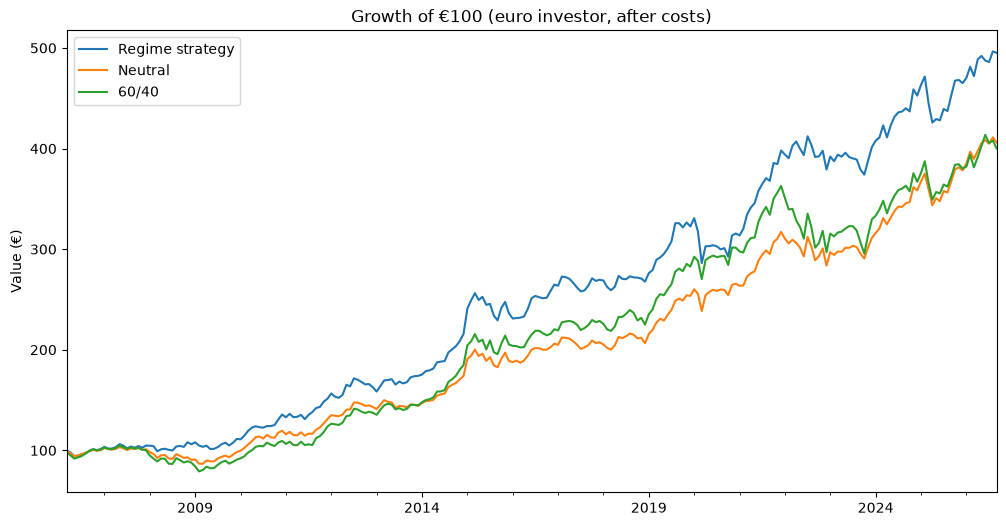

In [6]:
growth.plot(figsize=(12, 6), title="Growth of €100 (euro investor, after costs)")
plt.ylabel("Value (€)")
plt.show()

In [7]:
print(f"Average turnover per year: {turnover_ea.mean() * 12 * 100:.0f}% of the portfolio")
print(f"Total trading costs over the period: {turnover_ea.sum() * COST * 100:.1f}%")

Average turnover per year: 173% of the portfolio
Total trading costs over the period: 3.6%


### Trading activity

Turnover is about **173% of the portfolio per year**, down from 195% in the first version of the model, because the Economic Sentiment Indicator switches less often than industrial production. The portfolio is still repositioned every few months, since the regime changes whenever either growth or inflation switches.

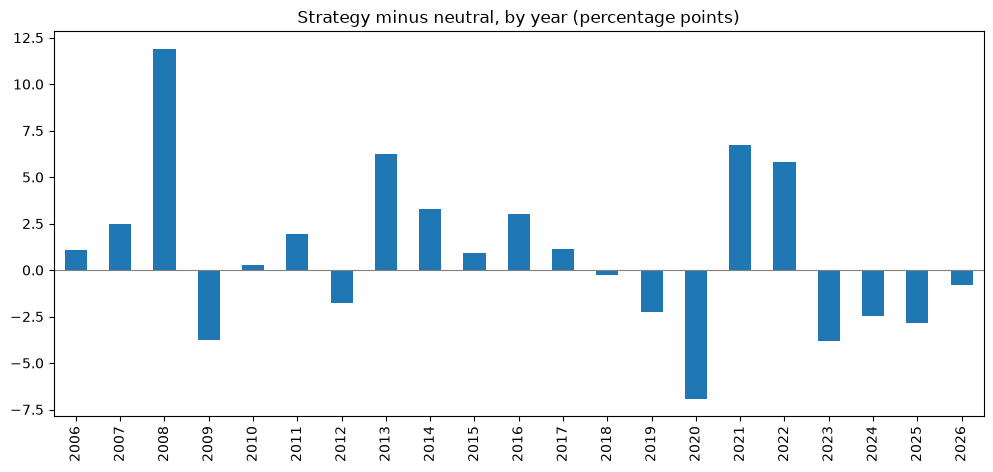

2006     1.1
2007     2.5
2008    11.9
2009    -3.8
2010     0.3
2011     1.9
2012    -1.8
2013     6.3
2014     3.3
2015     0.9
2016     3.0
2017     1.1
2018    -0.3
2019    -2.3
2020    -6.9
2021     6.7
2022     5.8
2023    -3.8
2024    -2.4
2025    -2.8
2026    -0.8
dtype: float64

In [8]:
yearly = (1 + results).groupby(results.index.year).prod() - 1
excess = (yearly["Regime strategy"] - yearly["Neutral"]) * 100

excess.plot(kind="bar", figsize=(12, 5), title="Strategy minus neutral, by year (percentage points)")
plt.axhline(0, color="grey", linewidth=0.8)
plt.show()

excess.round(1)

### Year-by-year

The strategy beat the neutral portfolio in **12 of 21 years**. The pattern is clear:

- **Wins when regimes develop gradually:** 2008 (+11.9 points), when sentiment fell well before the crash; 2013 (+6.3), the recovery from the euro crisis; 2021–2022 (+6.7, +5.8), the reopening boom and the switch to Stagflation the month after Russia's invasion of Ukraine.
- **Losses after sudden shocks:** 2020 (−6.9) and 2009 (−3.8). When sentiment collapses together with markets, the model turns defensive just as markets rebound.
- **Losses in directionless periods:** 2023–2026, four negative years in a row. Sentiment has been flat (about 95–97) since 2023, so it crosses its 12-month average back and forth on small moves, and the regime flips on noise.

**2008 alone contributes more than half of the total outperformance.** Without it, the advantage over the neutral portfolio would be roughly 0.4 points a year.

In [9]:
nets = {}
turns = {}

for lag in range(0, 5):
    sig = regimes["ea_regime"].shift(lag, freq="MS")
    net, _, turn = backtest(returns_eur, sig, regime_weights)
    nets[f"Lag {lag}"] = net
    turns[f"Lag {lag}"] = turn

all_nets = pd.DataFrame(nets).dropna()
all_nets["Neutral"] = results["Neutral"]
all_nets = all_nets.dropna()

lag_table = all_nets.apply(performance)
lag_table.loc["Turnover per year (%)"] = pd.Series(
    {name: t.mean() * 12 * 100 for name, t in turns.items()}
)
lag_table.round(2)

,Lag 0,Lag 1,Lag 2,Lag 3,Lag 4,Neutral
Annual return (%),9.02,8.08,8.06,8.33,7.65,7.04
Volatility (%),7.96,8.55,8.29,8.07,8.03,8.03
Return / volatility,1.13,0.95,0.97,1.03,0.95,0.88
Max drawdown (%),-11.06,-13.54,-10.69,-11.93,-10.53,-16.25
Turnover per year (%),170.04,172.96,172.96,169.55,169.55,NaN


## 5. How much does the publication lag cost?

The backtest was repeated with lags of 0 to 4 months, over the same period. Lag 0 is unrealistic: it assumes each month's regime is known instantly.

| | Lag 0 | **Lag 1** | Lag 2 | Lag 3 | Lag 4 | Neutral |
|---|---|---|---|---|---|---|
| Annual return | 9.02% | **8.08%** | 8.06% | 8.33% | 7.65% | 7.04% |
| Return / volatility | 1.13 | **0.95** | 0.97 | 1.03 | 0.95 | 0.88 |
| Max drawdown | −11.1% | **−13.5%** | −10.7% | −11.9% | −10.5% | −16.3% |

With sentiment data, performance is **similar for lags of 1 to 4 months**; the differences between them are within noise. This contrasts with the first version of the model (industrial production), where the edge fell from 2.3 points at lag 0 to 0.3 points at lag 3.

Likely reasons: sentiment regimes last longer (about 8 months vs 6 for industrial production), so a delay of a few months matters less; and sentiment is forward-looking, so even a few months old it still says something about the economy, while old output data does not.

## 6. Robustness: two halves of the sample

| | 2006–2015 | | | 2016–2026 | | |
|---|---|---|---|---|---|---|
| | **Strategy** | Neutral | 60/40 | **Strategy** | Neutral | 60/40 |
| Annual return | **9.13%** | 6.68% | 7.59% | **7.13%** | 7.38% | 6.40% |
| Return / volatility | **1.05** | 0.80 | 0.77 | **0.85** | 0.95 | 0.66 |
| Max drawdown | **−10.5%** | −16.3% | −24.5% | **−13.5%** | −10.6% | −18.6% |

The strategy clearly beat the neutral portfolio in 2006–2015, but **underperformed it in 2016–2026** on return, risk-adjusted return and drawdown. The whole edge comes from the first decade.

The neutral portfolio beat 60/40 on a risk-adjusted basis **in both halves**. This is the most robust result of the project.

## 7. Model versions

Two versions of the Euro area model were tested. The growth measure was changed for reasons identified **before** looking at backtest results: industrial production is published late, is noisy, and wrongly classified late 2022 as Overheating.

| | Version 1 | Version 2 |
|---|---|---|
| Euro area growth measure | Industrial production | Economic Sentiment Indicator |
| Lag | 3 months | 1 month |
| Annual return (neutral ≈ 7.0%) | 7.31% | 8.08% |
| Return / volatility (neutral 0.87–0.88) | 0.88 | 0.95 |
| Max drawdown | −15.6% | −13.5% |
| Turnover per year | 195% | 173% |

Every additional version tested increases the risk that one looks good by chance. Both versions are therefore reported.

## 8. Conclusions

1. **The regime framework contains information.** With perfect knowledge of the regime, tilts would have added about 2 points a year over a static portfolio.
2. **The choice of growth measure matters more than its speed.** Switching the Euro area from industrial production to the Economic Sentiment Indicator raised the realistic edge from 0.3 to about 1 point a year, and the result barely changed with lags of 1 to 4 months.
3. **The edge is period-dependent.** It comes almost entirely from 2006–2015, mainly 2008. Since 2016 the strategy has not beaten the static portfolio. The model adds value in gradually developing downturns and regime shifts, and loses after sudden shocks and in directionless markets.
4. **Diversification is the robust result.** A static portfolio holding gold, commodities, credit and cash alongside equities and bonds beat 60/40 on a risk-adjusted basis in both halves of the sample.

## 9. Possible extensions

- **Threshold rule:** only switch regime when sentiment moves clearly away from its average, with the threshold set in advance, to reduce switching in flat periods.
- **US / dollar version** of the backtest.
- **Higher trading costs** (e.g. 0.2% per trade).

## 10. Further robustness tests

In [10]:
cost_results = {}

for c in [0, 0.001, 0.002, 0.003]:
    net, _, _ = backtest(returns_eur, signal_ea, regime_weights, cost=c)
    cost_results[f"Cost {c * 100:.1f}%"] = net

cost_table = pd.DataFrame(cost_results)
cost_table["Neutral"] = results["Neutral"]
cost_table = cost_table.dropna()

cost_table.apply(performance).round(2)

,Cost 0.0%,Cost 0.1%,Cost 0.2%,Cost 0.3%,Neutral
Annual return (%),8.27,8.08,7.90,7.71,7.04
Volatility (%),8.55,8.55,8.55,8.55,8.03
Return / volatility,0.97,0.95,0.92,0.90,0.88
Max drawdown (%),-13.47,-13.54,-13.60,-13.66,-16.25


**Result.** Each 0.1% of trading cost reduces annual return by about 0.19 pts, consistent with an annual turnover of 173%. The gross edge over the neutral portfolio (1.2 pts at zero cost) would only disappear at around 0.65% per unit traded, or 0.35–0.4% on a risk-adjusted basis, since the strategy is slightly more volatile (8.55% vs 8.03%). This is several times the 0.02–0.10% typical for liquid ETFs, so transaction costs are not what limits the strategy; statistical significance is.

In [11]:
strategy_us, _, turnover_us = backtest(returns_usd, signal_us, regime_weights)

results_us = pd.DataFrame({
    "Regime strategy": strategy_us,
    "Neutral": static_portfolio(returns_usd, w_neutral),
    "60/40": static_portfolio(returns_usd, w_6040),
}).dropna()

print("Full period")
print(results_us.apply(performance).round(2))

halves = {
    "2006–2015": slice("2006", "2015"),
    "2016–2026": slice("2016", "2026"),
}
for name, period in halves.items():
    print()
    print(name)
    print(results_us.loc[period].apply(performance).round(2))

Full period
                     Regime strategy  Neutral  60/40
Annual return (%)               7.15     6.81   6.73
Volatility (%)                  9.02     9.17  10.88
Return / volatility             0.79     0.74   0.62
Max drawdown (%)              -19.10   -25.92 -32.43

2006–2015
                     Regime strategy  Neutral  60/40
Annual return (%)               5.08     5.67   6.57
Volatility (%)                  9.11     9.07  10.42
Return / volatility             0.56     0.62   0.63
Max drawdown (%)              -19.10   -25.92 -32.43

2016–2026
                     Regime strategy  Neutral  60/40
Annual return (%)               9.07     7.87   6.89
Volatility (%)                  8.94     9.28  11.33
Return / volatility             1.01     0.85   0.61
Max drawdown (%)              -15.19   -21.25 -28.19


**Result.** For a US investor (USD returns, US regimes, 2-month lag), the strategy's full-period edge over the neutral portfolio shrinks to 0.3 pts, against 1.0 pts in the euro version, consistent with a slower signal built on weaker growth data (industrial production rather than the ESI). The timing also reverses: the euro version gains 2.4 pts in 2006–2015 and loses 0.3 pts afterwards, while the US version loses 0.6 pts in the first half and gains 1.2 pts in the second. Because the edge appears in different periods depending on region and signal, it should not be treated as a reliable source of return.

The neutral portfolio's drawdown is much deeper for a US investor (−25.9% vs −16.3% in EUR): in 2008 the dollar rose against the euro, which cushions a euro investor's USD assets but adds a currency loss to a US investor's European equities. Diversification still helps in USD: the neutral portfolio has a much smaller drawdown than 60/40 in both halves (−25.9% vs −32.4%, −21.3% vs −28.2%), although on return/volatility the two are level in 2006–2015 (0.62 vs 0.63).

### 10(c) Block bootstrap of the excess return

In [12]:
excess = (results["Regime strategy"] - results["Neutral"]).dropna()

print(f"Months: {len(excess)}")
print(f"Average monthly excess: {excess.mean() * 100:.3f}%")
print(f"Annualised (x12): {excess.mean() * 12 * 100:.2f} pts")
print(f"Autocorrelation (lag 1): {excess.autocorr(lag=1):.2f}")

Months: 247
Average monthly excess: 0.084%
Annualised (x12): 1.01 pts
Autocorrelation (lag 1): 0.13


In [13]:
def block_bootstrap_mean(series, block=12, rng=None):
    values = series.to_numpy()
    n = len(values)
    n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=n_blocks)
    sample = np.concatenate([values[s:s + block] for s in starts])[:n]
    return sample.mean()

rng = np.random.default_rng(42)

for i in range(3):
    print(f"{block_bootstrap_mean(excess, rng=rng) * 12 * 100:.2f} pts")

3.15 pts
1.94 pts
0.80 pts


Observed edge: 1.01 pts
95% confidence interval: [-0.94, 2.97] pts
Share of samples with edge <= 0: 14.6%


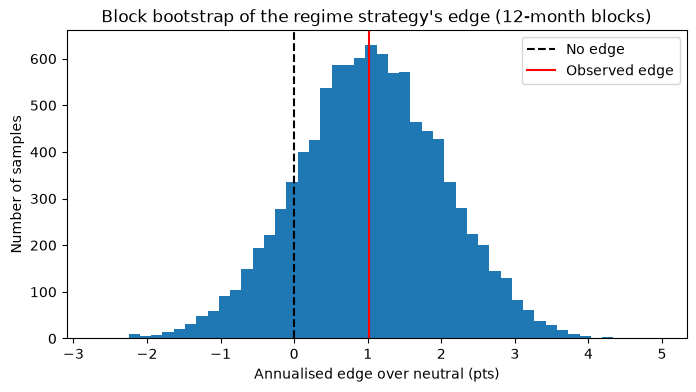

In [14]:
rng = np.random.default_rng(42)

boot = np.array([block_bootstrap_mean(excess, rng=rng) for _ in range(10_000)]) * 12 * 100

ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
share_negative = (boot <= 0).mean()

print(f"Observed edge: {excess.mean() * 12 * 100:.2f} pts")
print(f"95% confidence interval: [{ci_low:.2f}, {ci_high:.2f}] pts")
print(f"Share of samples with edge <= 0: {share_negative:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot, bins=50)
ax.axvline(0, color="black", linestyle="--", label="No edge")
ax.axvline(excess.mean() * 12 * 100, color="red", label="Observed edge")
ax.set_xlabel("Annualised edge over neutral (pts)")
ax.set_ylabel("Number of samples")
ax.set_title("Block bootstrap of the regime strategy's edge (12-month blocks)")
ax.legend()
plt.show()

**Result.** I tested the monthly return difference between the strategy and the neutral portfolio with a block bootstrap (10,000 samples, 12-month blocks to preserve the persistence created by regimes). The observed edge is 1.01 pts per year, but the 95% confidence interval is wide, [−0.94, 2.97] pts, and 14.6% of samples show no outperformance. The edge is therefore not statistically significant in this sample: the data cannot distinguish a small genuine edge from luck. The interval is consistent with the 0.4–0.9% annual outperformance over a static allocation reported by Blitz & van Vliet (2011) from 60 years of data.

In [15]:
start = excess.index.min() - pd.DateOffset(months=LAG_EA)
signal = signal_ea.dropna().loc[start:]

episode_id = (signal != signal.shift()).cumsum()
episodes = [group.to_numpy() for _, group in signal.groupby(episode_id)]

print(f"Months: {len(signal)}")
print(f"Episodes: {len(episodes)}")
print(signal.value_counts())

Months: 249
Episodes: 53
ea_regime
Overheating    68
Goldilocks     68
Slowdown       68
Stagflation    45
Name: count, dtype: int64


In [16]:
print(signal.index.min(), "to", signal.index.max())
print("Sorted:", signal.index.is_monotonic_increasing)
print("Unique dates:", signal.index.is_unique)
print("Switches:", (signal != signal.shift()).sum() - 1)

2006-02-01 00:00:00 to 2026-10-01 00:00:00
Sorted: True
Unique dates: True
Switches: 52


In [17]:
def shuffle_regimes(signal, episodes, rng):
    order = rng.permutation(len(episodes))
    shuffled = np.concatenate([episodes[i] for i in order])
    return pd.Series(shuffled, index=signal.index, name=signal.name)

rng = np.random.default_rng(42)
test = shuffle_regimes(signal, episodes, rng)

print(test.value_counts())
print()
print(pd.DataFrame({"Real": signal, "Shuffled": test}).head(12))

ea_regime
Slowdown       68
Goldilocks     68
Overheating    68
Stagflation    45
Name: count, dtype: int64

                   Real  Shuffled
2006-02-01  Overheating  Slowdown
2006-03-01  Overheating  Slowdown
2006-04-01   Goldilocks  Slowdown
2006-05-01  Overheating  Slowdown
2006-06-01  Overheating  Slowdown
2006-07-01  Overheating  Slowdown
2006-08-01  Overheating  Slowdown
2006-09-01   Goldilocks  Slowdown
2006-10-01   Goldilocks  Slowdown
2006-11-01   Goldilocks  Slowdown
2006-12-01   Goldilocks  Slowdown
2007-01-01   Goldilocks  Slowdown


Real strategy: 8.08%
Shuffled strategies: mean 6.86%, 95th percentile 8.35%
Share of shuffles the real strategy beats: 90.4%
p-value (shuffles >= real): 0.096


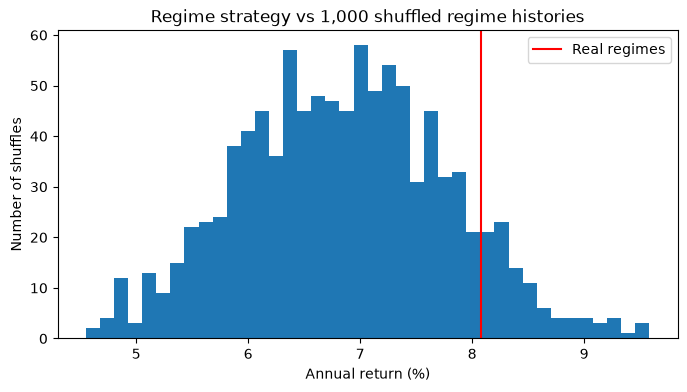

In [18]:
def annual_return(r):
    return ((1 + r).prod() ** (12 / len(r)) - 1) * 100

real = annual_return(results["Regime strategy"].loc[excess.index])

rng = np.random.default_rng(42)
perm = []

for i in range(1_000):
    shuffled_signal = shuffle_regimes(signal, episodes, rng)
    net, _, _ = backtest(returns_eur, shuffled_signal, regime_weights)
    perm.append(annual_return(net.loc[excess.index]))

perm = np.array(perm)

print(f"Real strategy: {real:.2f}%")
print(f"Shuffled strategies: mean {perm.mean():.2f}%, 95th percentile {np.percentile(perm, 95):.2f}%")
print(f"Share of shuffles the real strategy beats: {(perm < real).mean():.1%}")
print(f"p-value (shuffles >= real): {(perm >= real).mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm, bins=40)
ax.axvline(real, color="red", label="Real regimes")
ax.set_xlabel("Annual return (%)")
ax.set_ylabel("Number of shuffles")
ax.set_title("Regime strategy vs 1,000 shuffled regime histories")
ax.legend()
plt.show()

**Result.** To test whether the regimes carry information, I shuffled whole regime episodes 1,000 times (keeping the number of months in each regime and the episode lengths) and reran the backtest with the same tilts and costs. The real strategy (8.08%) beats 90.4% of the shuffled versions (p ≈ 0.10), which is weak evidence that the regimes contain information, significant at the 10% level but not at 5%. The shuffled strategies average 6.86%, roughly the neutral portfolio minus trading costs, so the edge comes from the timing of the tilts rather than from a different average allocation. This is consistent with the bootstrap result (14.6% of samples showing no edge).

Two caveats. Shuffling can merge adjacent episodes of the same regime, so the shuffled strategies trade slightly less and pay lower costs, which makes the test mildly conservative. On the other hand, two growth measures were tested (industrial production and the ESI) and the better one is reported, which makes the p-value somewhat optimistic.

### 10(e) Excluding 2008

In [19]:
no_2008 = results.loc[results.index.year != 2008]

no_2008.apply(performance).round(2)

,Regime strategy,Neutral,60/40
Annual return (%),8.44,8.04,8.06
Volatility (%),8.55,7.87,9.55
Return / volatility,0.99,1.02,0.84
Max drawdown (%),-13.54,-10.56,-18.55


**Result.** Excluding 2008, the strategy's edge over the neutral portfolio falls from 1.04 to 0.40 pts per year, and on a risk-adjusted basis the neutral portfolio is ahead (return/volatility 1.02 vs 0.99). Most of the return edge and all of the risk-adjusted edge therefore come from a single year, when the regimes correctly signalled a defensive position during the financial crisis. The diversification result is unaffected: without 2008, the neutral portfolio matches the 60/40 return (8.04% vs 8.06%) with lower volatility (7.87% vs 9.55%) and a smaller drawdown (-10.6% vs - 18.6%).

### 10(f) Stock–bond correlation by regime

In [20]:
df = pd.DataFrame({
    "VGK": returns_eur["VGK"],
    "SPY": returns_eur["SPY"],
    "TLT": returns_eur["TLT"],
    "regime": signal,
}).dropna()

corr_table = df.groupby("regime").apply(lambda g: pd.Series({
    "Months": len(g),
    "VGK–TLT": g["VGK"].corr(g["TLT"]),
    "SPY–TLT": g["SPY"].corr(g["TLT"]),
}))

corr_table.loc["All months"] = [len(df), df["VGK"].corr(df["TLT"]), df["SPY"].corr(df["TLT"])]

corr_table.round(2)

,Months,VGK–TLT,SPY–TLT
regime,,,
Goldilocks,68.0,0.03,0.32
Overheating,66.0,-0.33,-0.11
Slowdown,68.0,-0.25,-0.03
Stagflation,45.0,-0.23,0.05
All months,247.0,-0.23,0.01


In [21]:
df_2022 = df.loc["2022"]
print(f"VGK–TLT correlation in 2022: {df_2022['VGK'].corr(df_2022['TLT']):.2f}")
print(df_2022["regime"].value_counts())

VGK–TLT correlation in 2022: 0.34
regime
Stagflation    9
Overheating    3
Name: count, dtype: int64


**Result.** The correlation between European equities (VGK) and long US Treasuries (TLT) in euro terms is negative over the full sample (-0.23) and in every regime except Goldilocks (+0.03), where the hedge matters least. Contrary to the common view, it remains negative on average in Stagflation (-0.23): this regime mixes inflation shocks with growth shocks such as mid-2008, when bonds rallied as a safe haven, and for a euro investor a rising dollar during stress adds to TLT's hedging value. In 2022, however, a true inflation shock that the signal classified mostly as Stagflation (9 of 12 months), the correlation was +0.34 and bonds failed as a hedge. This is the year the regime tilts added most value relative to static diversification. With 45-68 months per regime, differences between the non-Goldilocks regimes are within estimation error.